# FreshEye — Detección de Ingredientes y Recomendación de Recetas mediante Visión Artificial

**Informe técnico de desarrollo del proyecto**

 **FreshEye**, una aplicación web que utiliza un modelo de detección de objetos (**YOLOv8m**) para identificar ingredientes de cocina a partir de una fotografía, y que recomienda recetas en función de los ingredientes detectados.

---

**Repositorio:** `FreshEye` https://github.com/BlaD3r035/FreshEye &nbsp;|&nbsp; **Autor(es):** _Samuel Alejandro Estepa Estupiñan, Jesus David Jaimes Garcia_ &nbsp;|&nbsp;


## Índice

1. [Introducción y contexto del problema](#1)
2. [Arquitectura general del sistema](#2)
3. [Adquisición de la imagen](#3)
4. [Preprocesamiento](#4)
5. [Segmentación](#5)
6. [Clasificación](#6)
7. [Limitaciones y trabajo futuro](#7)



<a id='1'></a>
## 1. Introducción y contexto del problema

**Problema:** Uno de los mayores problema al cocinar en casa es decidir *qué preparar* con los ingredientes que ya se tienen disponibles, especialmente cuando no se sabe con certeza qué hay o cuando se quiere evitar el desperdicio de alimentos.

**Propuesta de solución:** FreshEye permite al usuario tomar una fotografía de los ingredientes que tiene sobre su mesa, detectar automáticamente cuáles de un catálogo de **20 ingredientes** están presentes, y recibir una lista de **recetas recomendadas y ordenadas por porcentaje de coincidencia** con lo detectado.

### 1.1 Catálogo de ingredientes (clases del modelo)


In [ ]:
CLASSES = [
    "Aguacate" ,
    "Ajo" ,
    "Auyama" ,
    "Berenjena" ,
    "Carne_de_res" ,
    "Cebolla" ,
    "Champinon" ,
    "Cilantro" ,
    "Huevo" ,
    "Lechuga" ,
    "Limon",
    "Papa" ,
    "Pasta",
    "Pechuga_de_pollo",
    "Pepino",
    "Perejil",
    "Pimenton",
    "Tomate",
    "Zanahoria",
    "brocoli",
]



<a id='2'></a>
## 2. Arquitectura general del sistema



- **Frontend:** captura la imagen desde la cámara del dispositivo y consume la API.
- **Backend (FastAPI):** expone `/detect` (inferencia YOLO) y `/recipes/recommend` (matching de recetas).
- **Modelo:** YOLOv8m entrenado sobre 20 clases de alimentos(`models/best.pt`).
- **Base de recetas:** `util/recipes.json`, cruzado contra los ingredientes detectados.

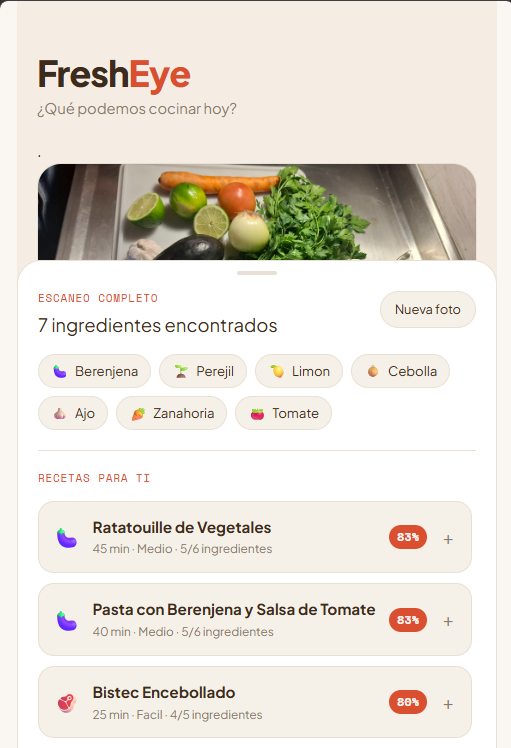

<a id='3'></a>
## 3. Adquisición de la imagen

### 3.1 Fuentes de datos

El dataset final combina **dos fuentes**:

| Fuente | Cantidad aprox. | Rol                                                                      |
|---|---|--------------------------------------------------------------------------|
| Imágenes propias capturadas | ~1.500 | Condiciones reales de uso                                                |
| Dataset externo open-source | ~1.900 | Reconocimiento de alimentos en otras condiciones y facilidad de recursos |



### 3.2 Condiciones de captura (imágenes propias)

- **Formato:** JPEG/PNG, resolución de cámara de celular 1920px*1080px
- **Variedad controlada y documentada:**
  - Múltiples ángulos por ingrediente (cenital, 45°, lateral).
  - Ingredientes aislados y en combinación .
  - Variación de iluminación (luz natural / artificial) y de fondo (mesón, tabla, plato, refrigerador).
  - Ingredientes en distintos estados de frescura/corte (entero, cortado), reflejando el uso real.

### 3.3 Anotación (bounding boxes) — Roboflow

Las cajas delimitadoras (*bounding boxes*) para las 20 clases fueron anotadas asistidamente  en **Roboflow**, plataforma elegida por:


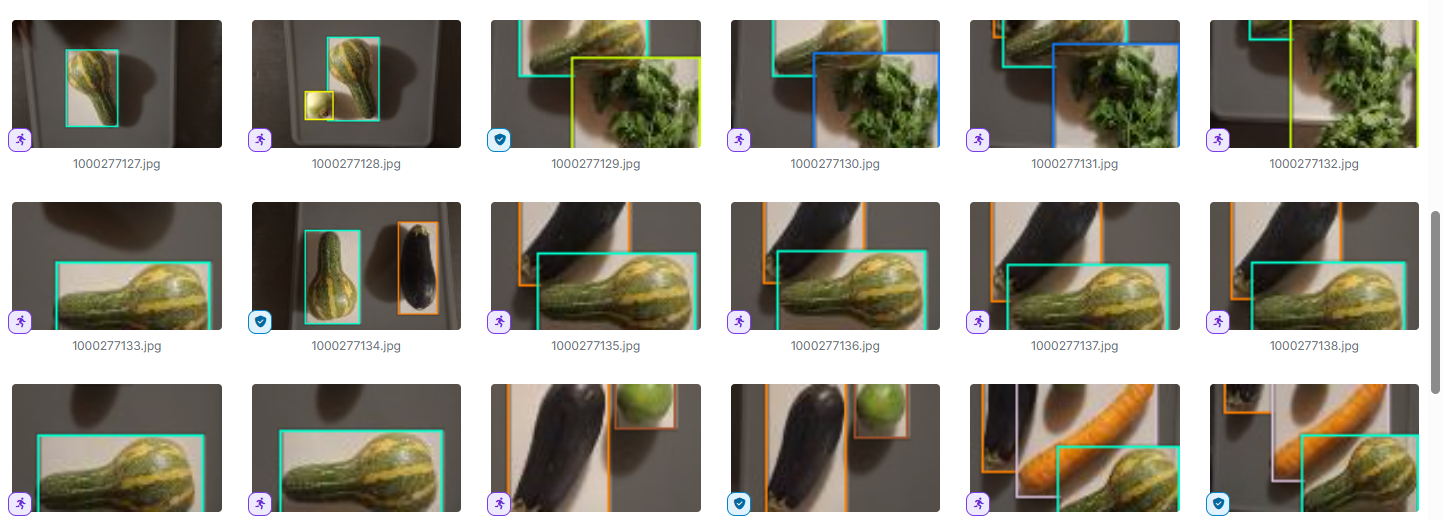

<a id='4'></a>
## 4. Preprocesamiento

El preprocesamiento ocurre justo cuando la imagen llega al endpoint y antes de pasarlo al modelo para su resultado

### Resize



In [ ]:
 # resize de imagen max 1024, mejor manejo de la imagen y de igual manera en yolo se reduce a 640
def resize(self, img: np.ndarray) -> np.ndarray:
    h, w = img.shape[:2]
    scale = self.max_dim / max(h, w)
    if scale < 1:
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img


- Se usa para normalizar las imagenes que llegan de diferentes resoluciones por las tomas de diferentes dispositivos, de igual manera se mejora el performance de los demas algoritmos

### Reducción de ruido — Filtro Bilateral, Mejora de contraste — CLAHE y Unsharp Masking


In [ ]:
 # filtro bilateral (reducción de ruido sin perder bordes )
def denoise(self, img: np.ndarray) -> np.ndarray:
    return cv2.bilateralFilter(img, d=7, sigmaColor=50, sigmaSpace=50)


In [ ]:
 # ecualizacion de histograma (mantiene contraste pero evita saturación de colores)
def enhance_contrast(self, img: np.ndarray) -> np.ndarray:
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y = self.clahe.apply(y)
    ycrcb = cv2.merge((y, cr, cb))
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)


In [ ]:
 # mejora de nitidez (aumenta el contraste de los bordes, mejor para hojas y detalles finos)
def sharpen(self, img: np.ndarray) -> np.ndarray:
    blur = cv2.GaussianBlur(img, (0, 0), sigmaX=3)
    return cv2.addWeighted(img, 1.5, blur, -0.5, 0)


**Justificación:**
- se usa un filtro bilineal con el fin de reducir el ruido granular sin suavizar los bordes importantes como el gaussiano
- trabajamos en el canal Y para ajustar la luminancia buscando neutralizar la luz fria/calida de las diferentes fuentes de luz en cocinas
- el unsharp masking regresa la definición de las texturas y bordes perdidos por los demas preprocesamientos
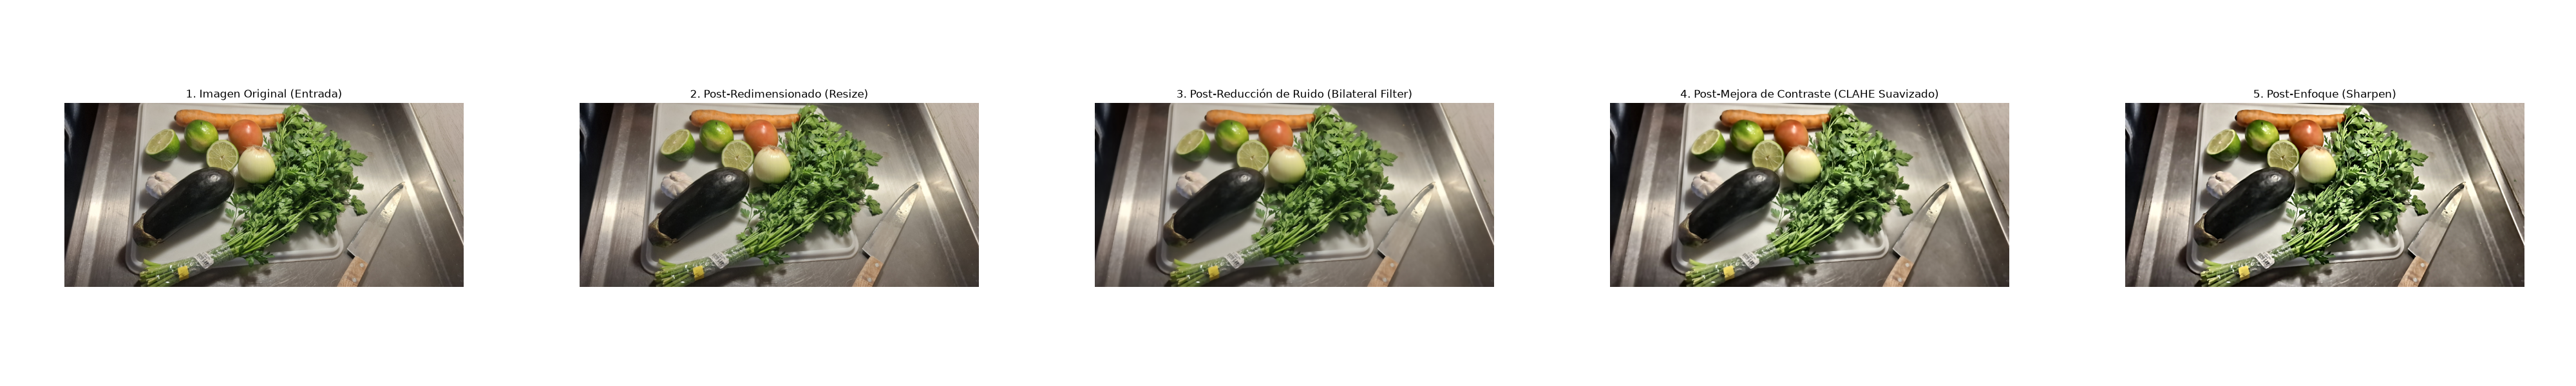

### 4.3 Evidencia de mejora
Se hizo uso de estos algoritmos para realizar las metricas del modelo sobre las imagenes val.
La evidencia medible de que el preprocesamiento/aumentación fue efectivo se refleja indirectamente en las métricas de generalización del modelo : un **mAP@0.5 global de 0.752** sobre un conjunto de validación con condiciones variadas confirma que el modelo no quedó sobre-ajustado a un único tipo de imagen.

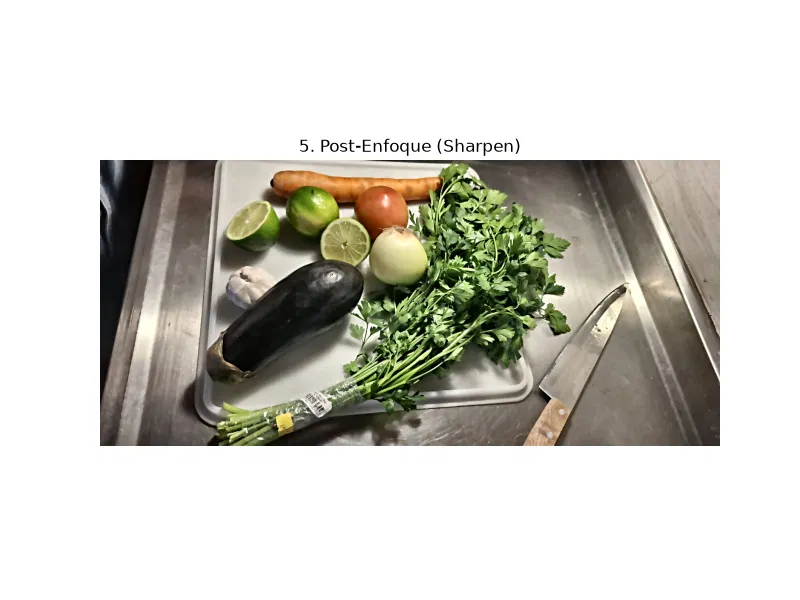


<a id='5'></a>
## 5. Segmentación

### 5.1 Decisión de diseño: detección (bounding box) en lugar de segmentación por píxel

FreshEye no implementa segmentación pixel a pixel.

Esta decisión se tomó con forme a los siguientes puntos:

| Criterio | Segmentación por píxel                                                     | Detección por bounding box                                              |
|---|----------------------------------------------------------------------------|-------------------------------------------------------------------------|
| Información que necesita el negocio | Solo se necesita **qué** ingrediente hay y su lugar aproximado             | mas eficiente a la hora de realizar la solicitud
| Costo de anotación | Requiere máscaras pixel a pixel (costoso de verificar para 3400+ imagenes) | Las box son mas faciles de anotar para esa cantidad de imagenes         |
| Velocidad de inferencia  | Mayor carga computacional                       | Menor latencia                                                          |


**Conclusión de la decisión:** dado que el objetivo final es *reconocer presencia de ingredientes para recomendar recetas* (y no, por ejemplo, medir volumen/porcentaje de plato ocupado por cada alimento), la caja delimitadora aporta toda la información espacial que el flujo de negocio requiere, a un costo de anotación y cómputo notablemente menor.

### 5.2 manejo de boxes
El modelo separa los ingredientes mediante cordenadas de esquinas dadas por el modelo:

- **bounding box regression:** cada detección produce `[x1, y1, x2, y2]`, actuando como una región de interés (ROI) que aísla al ingrediente del resto de la escena.
- **NMS:** el NMS "agnostic_nms" evita que se detecte un alimento diferente sobre otro alimento, creando dobles o falsos positivos


In [ ]:
    results = self.model(
        img_array,
        verbose=False,
        conf=self.confidence_threshold,
        augment=True,
        agnostic_nms=True, # nms
    )[0]

    h, w = img_array.shape[:2]

    detecciones = []
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist() # cordenadas de esquinas box
        clase_id = int(box.cls[0])
        confianza = round(float(box.conf[0]), 2)
        clase = self.model.names[clase_id]

        detecciones.append({
            "clase": clase,
            "confianza": confianza,
            "box": [
                round(x1 / w, 3),
                round(y1 / h, 3),
                round(x2 / w, 3),
                round(y2 / h, 3),
            ],
        })

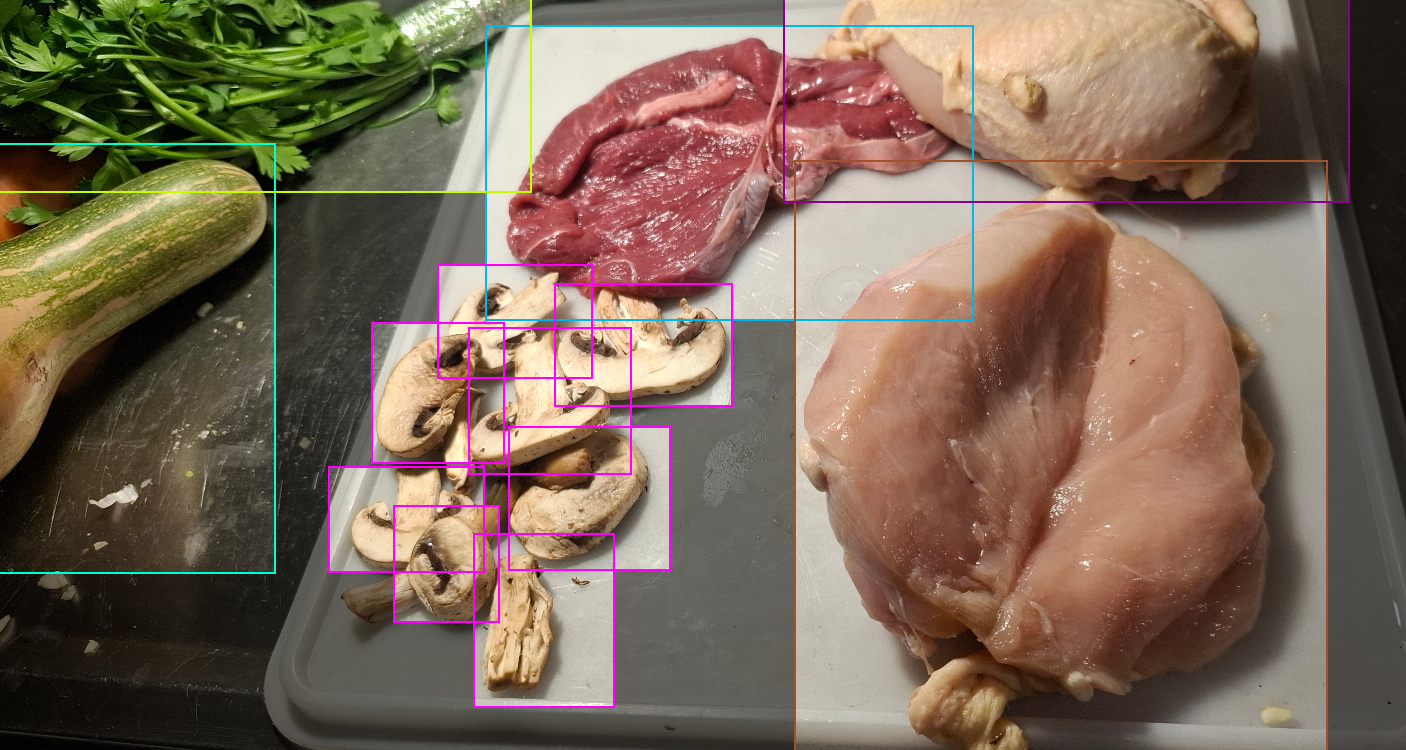


<a id='6'></a>
## 6. Clasificación

### 6.1 Selección del modelo:


La elección de **YOLOv8m** responde directamente a la solicitud manteniendo una latencia reducida para lo que se requiere en el proyecto, perfecto para la clasificación rapida de ingredientes.

### 6.2 Manejo de entrenamiento y validación

- **Splits:** seccionamiento del dataset train/test/val para la verificación y la correcta medición del modelo sobre imagenes no repetidas
- **Transferencia de aprendizaje:** se parte de pesos preentrenados (`yolov8m.pt` sobre COCO) en lugar de entrenar desde cero, aprovechando características genéricas ya aprendidas  y reduciendo drásticamente el número de imágenes necesarias para converger


In [ ]:
#
import argparse
from pathlib import Path
from ultralytics import YOLO

BASE_DIR = Path(".").resolve()
DATA_YAML = BASE_DIR / "data.yaml"

parser = argparse.ArgumentParser()
parser.add_argument("--model", default="yolov8m.pt")
parser.add_argument("--epochs", type=int, default=150)
parser.add_argument("--imgsz", type=int, default=640)
parser.add_argument("--batch", type=int, default=16)
parser.add_argument("--patience", type=int, default=30)
parser.add_argument("--workers", type=int, default=4)
args, _ = parser.parse_known_args([])

print("Configuración de entrenamiento usada:")
for k, v in vars(args).items():
    print(f"  {k}: {v}")


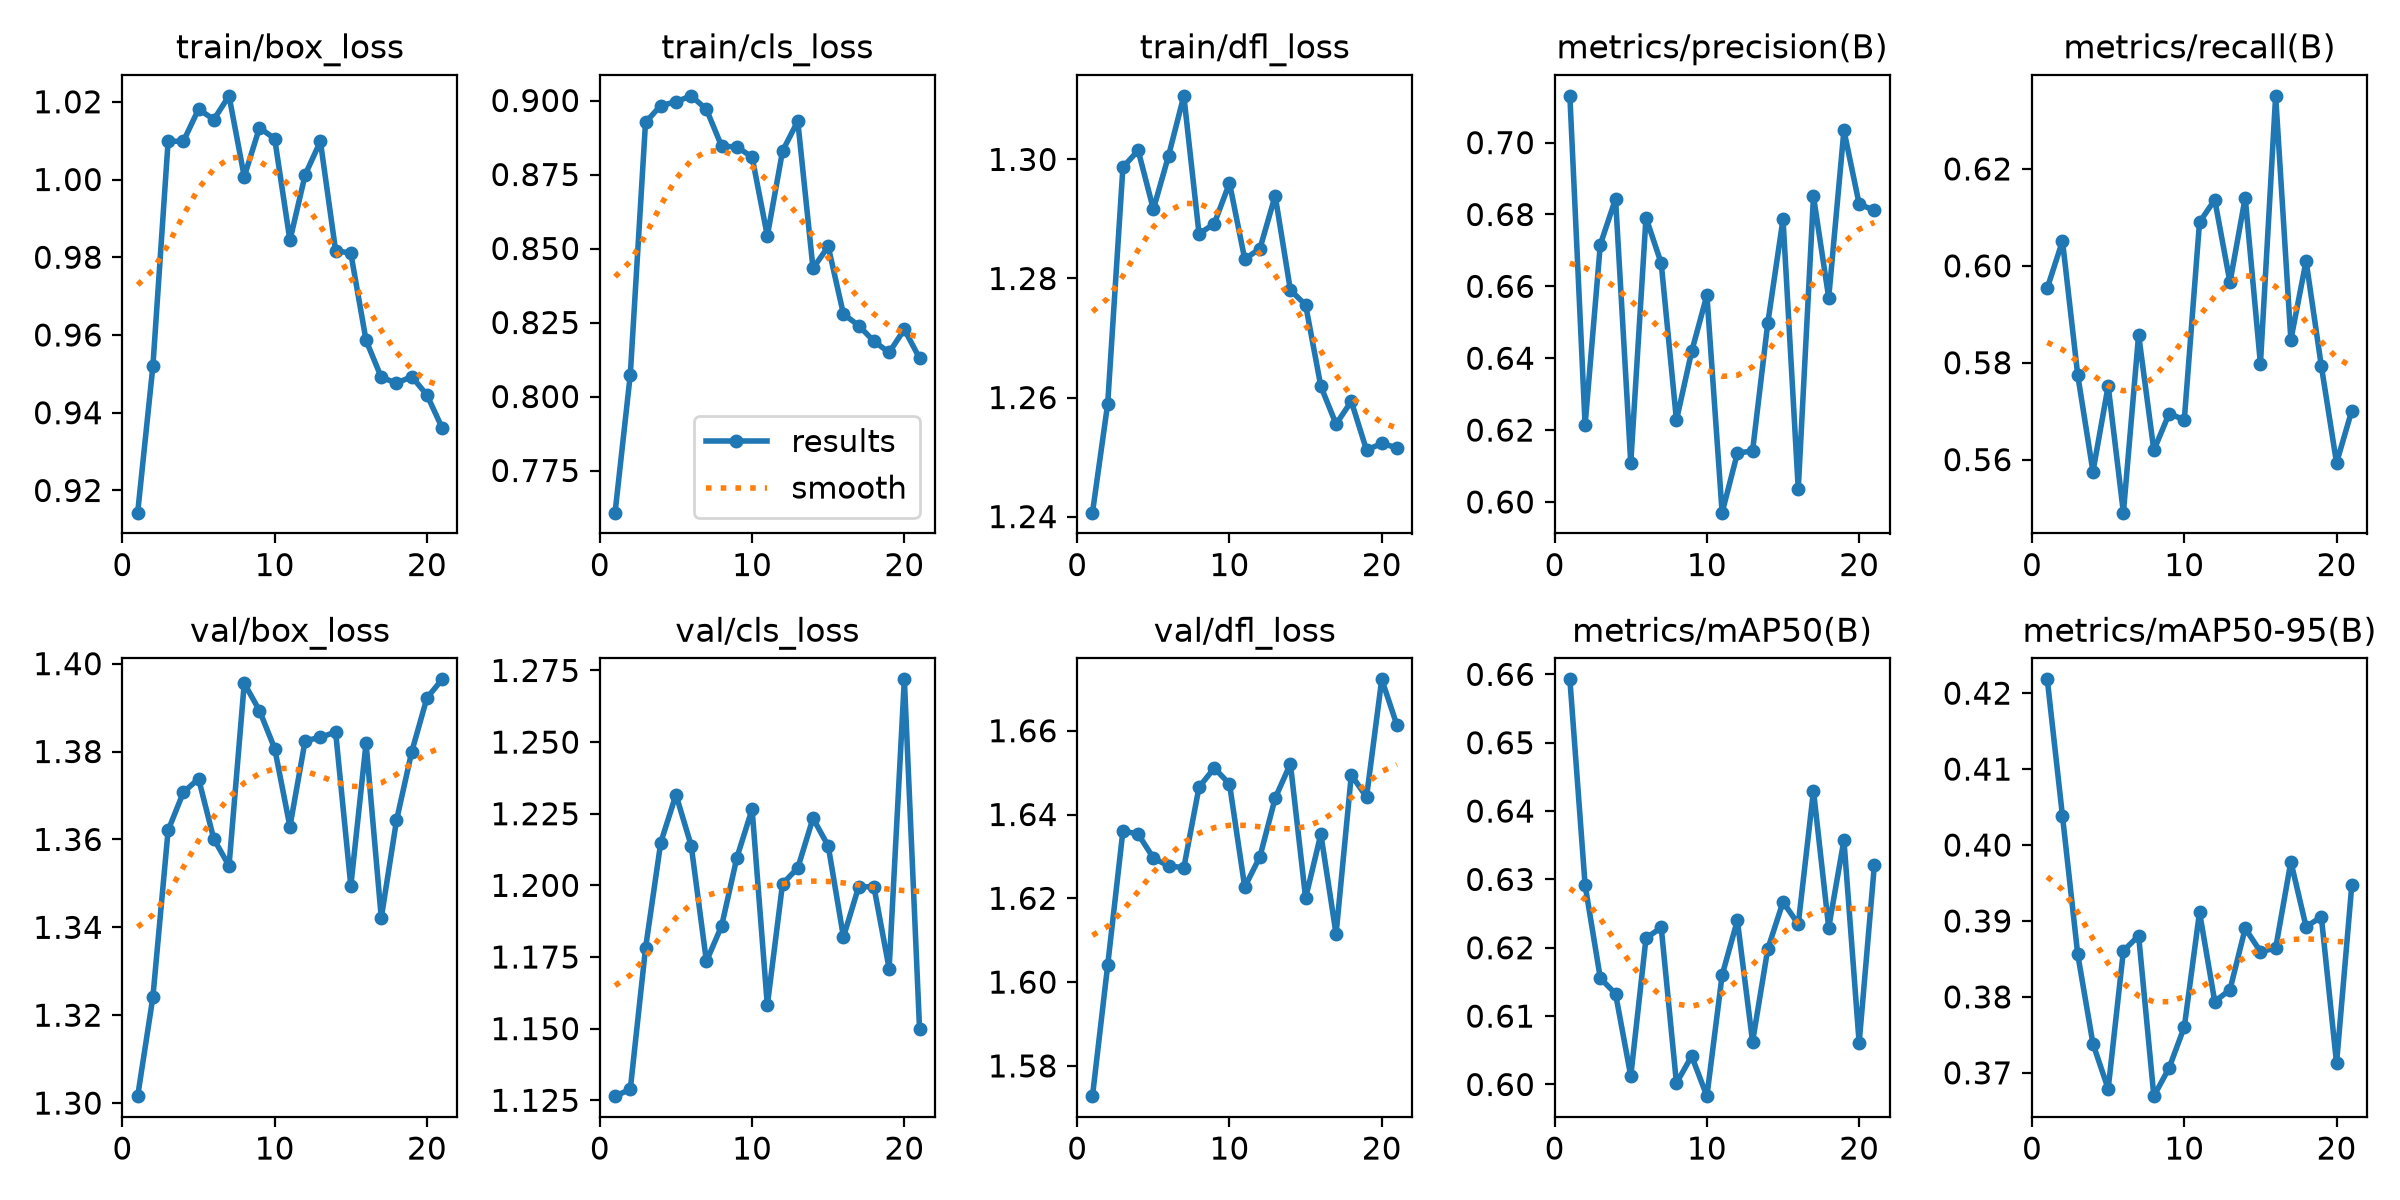
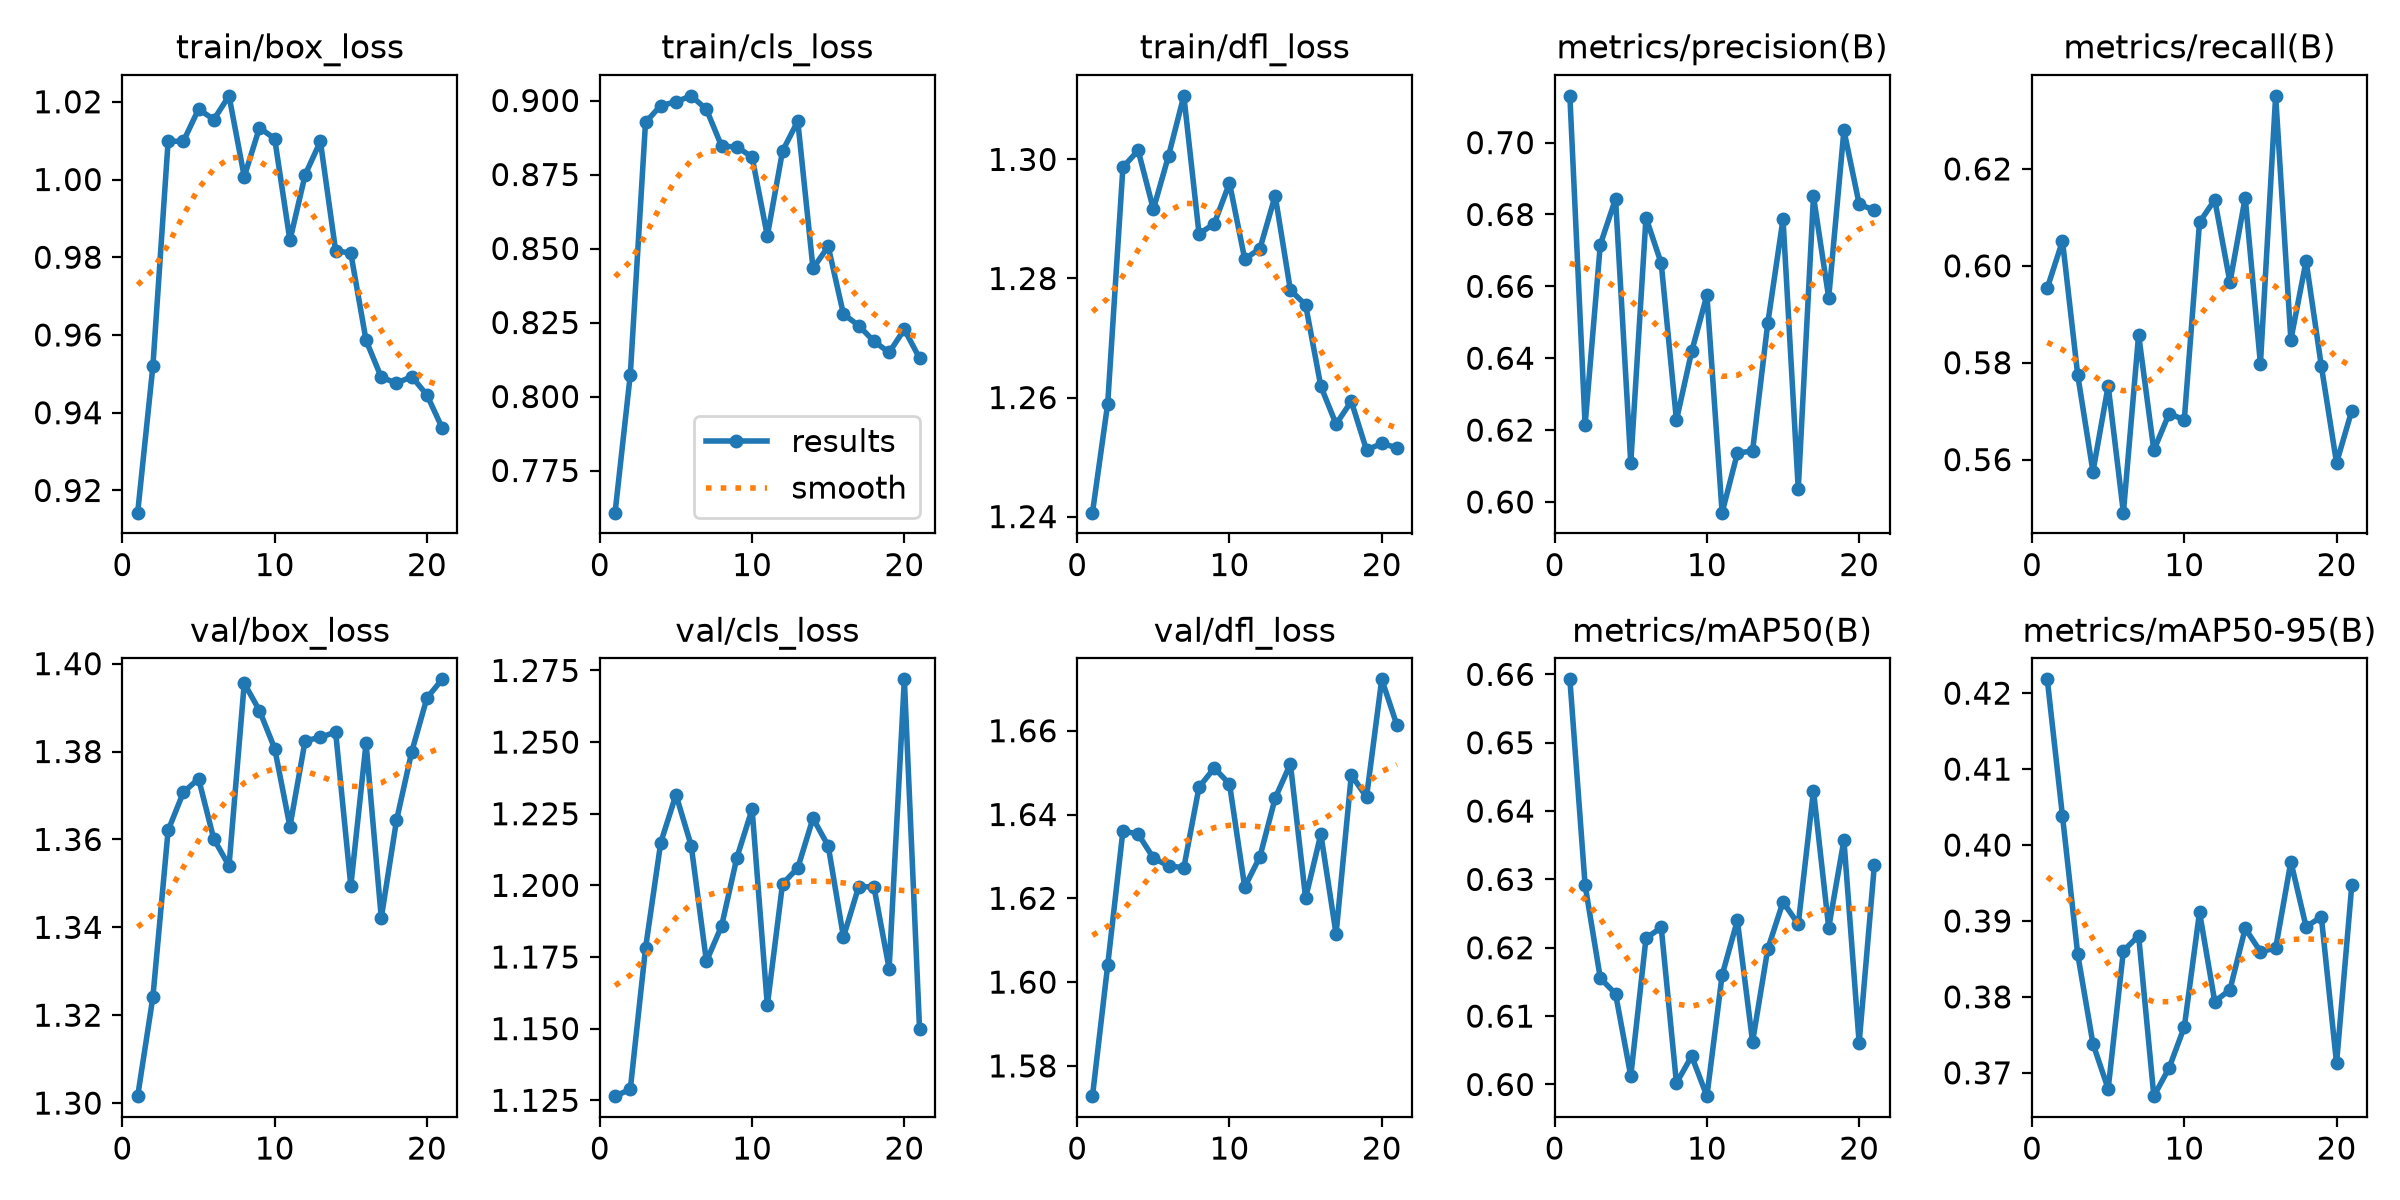

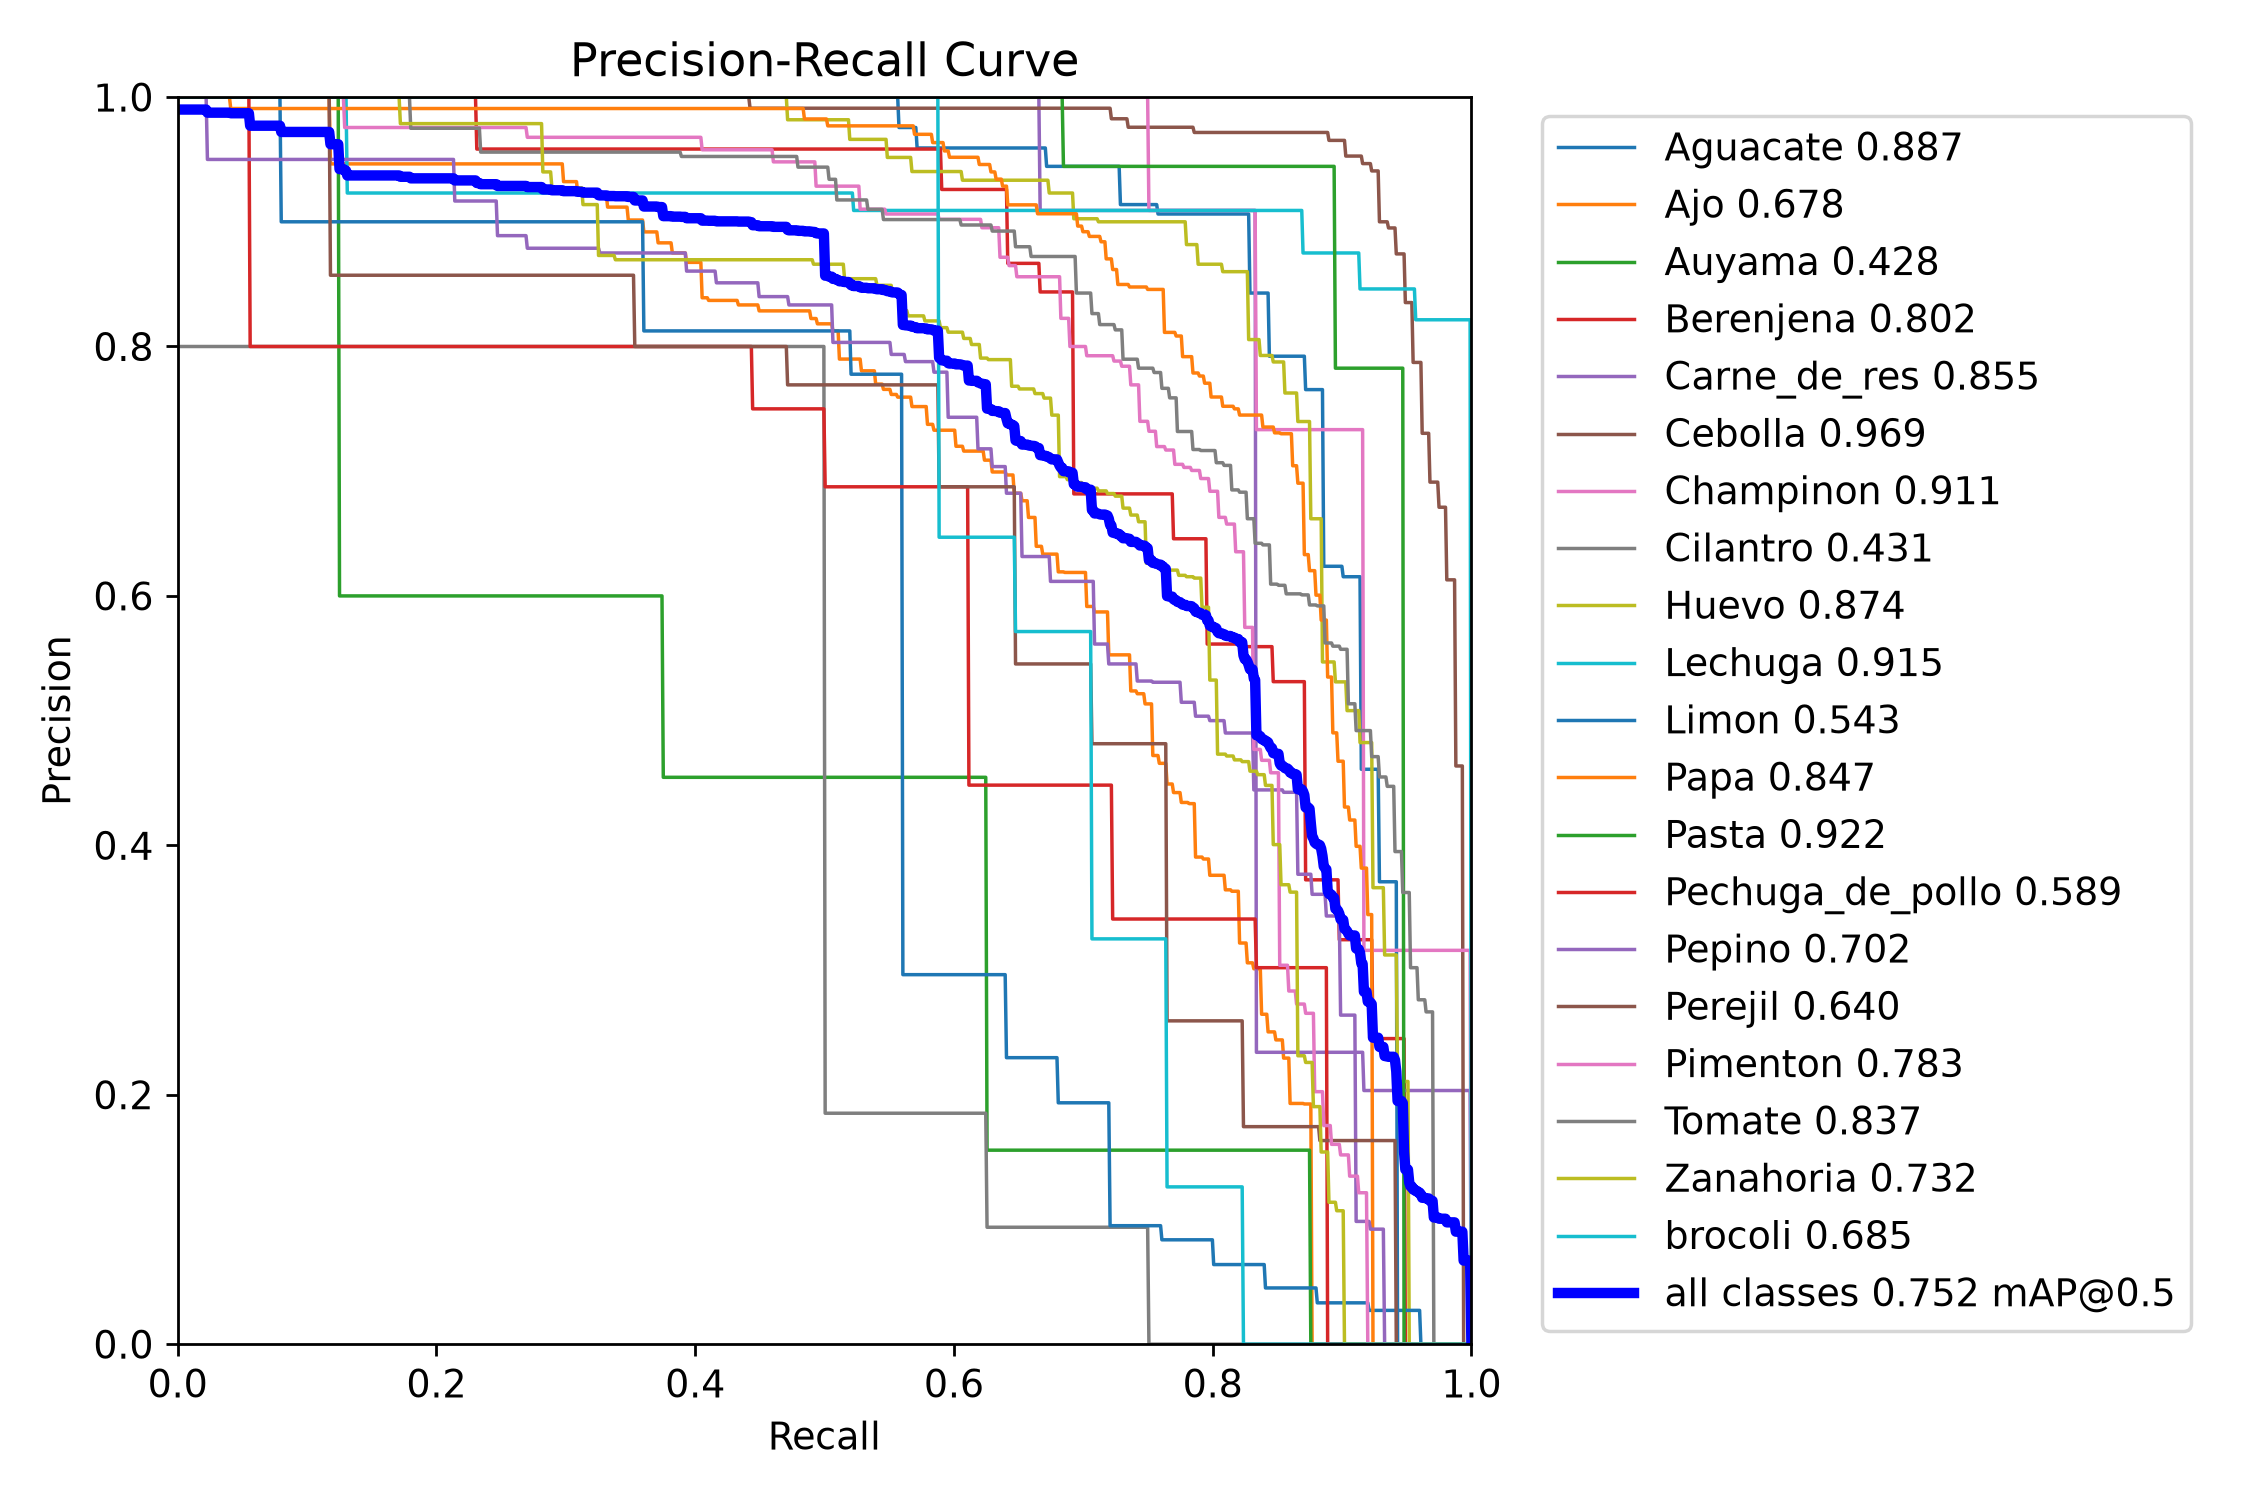


<a id='7'></a>
## 7. Limitaciones y trabajo futuro

| Limitación identificada                        | Evidencia | Propuesta de mejora                                                                                                   |
|------------------------------------------------|---|-----------------------------------------------------------------------------------------------------------------------|
|
| Bajo desempeño en clases visualmente similares | Cilantro vs. Perejil; confusión cruzada visible en la matriz | Aumentar ejemplos específicos de estos pares e incorporar variables auxiliares  |
| Clases con pocos datos                         | Auyama , Carne de res  | Ampliar el dataset propio específicamente para estas clases (activo, no pasivo, dado que ya se identificó el déficit) |

